# Importing Packages

In [ ]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd
import pylab as pl
import numpy as np
import seaborn as sns
from sklearn import preprocessing
from sklearn.impute import KNNImputer

# Reading the File

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/HousePrice1.csv")

# EDA

In [ ]:
df.head()

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63.0,1,True,True,True,Shahran,1850000000,61666.67
1,60.0,1,True,True,True,Shahran,1850000000,61666.67
2,79.0,2,True,True,True,Pardis,550000000,18333.33
3,NaN,2,True,True,True,Shahrake Qods,902500000,30083.33
4,123.0,2,True,True,True,Shahrake Gharb,7000000000,233333.33


In [ ]:
rows, columns = df.shape
print(f'rows: {rows} \n columns: {columns}')

rows: 3479 
 columns: 8


In [ ]:
df.dtypes

Area          float64
Room            int64
Parking          bool
Warehouse        bool
Elevator         bool
Address        object
Price           int64
Price(USD)    float64
dtype: object

In [ ]:
df.describe(include="all")

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
count,3.470000e+03,3479.000000,3479,3479,3479,3456,3.479000e+03,3.479000e+03
unique,NaN,NaN,2,2,2,192,NaN,NaN
top,NaN,NaN,True,True,True,Punak,NaN,NaN
freq,NaN,NaN,2950,3182,2739,161,NaN,NaN
mean,8.766678e+06,2.079908,NaN,NaN,NaN,NaN,5.359023e+09,1.786341e+05
std,3.171369e+08,0.758275,NaN,NaN,NaN,NaN,8.099935e+09,2.699978e+05
min,3.000000e+01,0.000000,NaN,NaN,NaN,NaN,3.600000e+06,1.200000e+02
25%,6.900000e+01,2.000000,NaN,NaN,NaN,NaN,1.418250e+09,4.727500e+04
50%,9.000000e+01,2.000000,NaN,NaN,NaN,NaN,2.900000e+09,9.666667e+04
75%,1.200000e+02,2.000000,NaN,NaN,NaN,NaN,6.000000e+09,2.000000e+05


In [ ]:
df.isnull().sum()

Area           9
Room           0
Parking        0
Warehouse      0
Elevator       0
Address       23
Price          0
Price(USD)     0
dtype: int64

## Getting the top 10 most frequent addresses

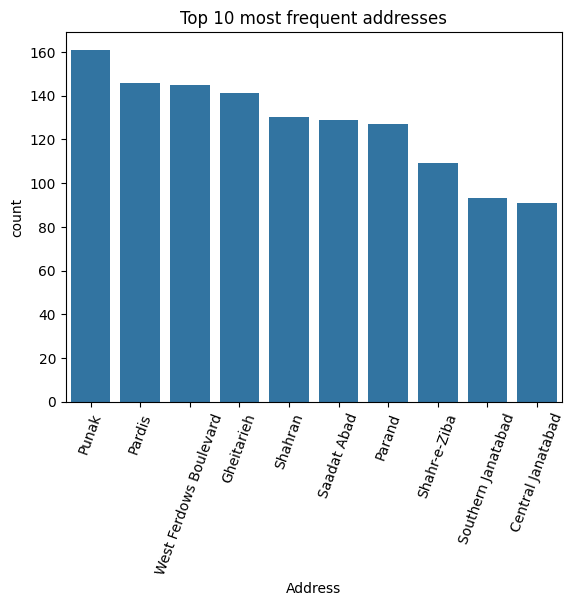

In [ ]:
df_topadress = df.Address.value_counts()[:10]
sns.barplot(df_topadress)
plt.title("Top 10 most frequent addresses")
plt.xticks(rotation=70)
plt.show()

# Data Cleaning

## Data cleaning.1 -> Dropping duplicates

In [ ]:
df.duplicated().sum()

207

In [ ]:
df.drop_duplicates(inplace=True)

## Data cleaning.2 -> Label Encoding

In [ ]:
encoder = preprocessing.LabelEncoder()
df['Address'] = encoder.fit_transform(df['Address'])

# For columns with only "True" and "False" values you can simply:
df['Parking'] = df['Parking'].astype(int)
df['Warehouse'] = df['Warehouse'].astype(int)
df['Elevator'] = df['Elevator'].astype(int)

## Data cleaning.3 -> Handling Missing Values

In [ ]:
df.isnull().sum()

Area          9
Room          0
Parking       0
Warehouse     0
Elevator      0
Address       0
Price         0
Price(USD)    0
dtype: int64

In [ ]:
# Dropping Adress Null Values
df.dropna(subset=["Address"], inplace=True)

In [ ]:
# Replacing Area Null Values using KNN Imputer
features = ["Area", "Room", "Parking",	"Warehouse", "Elevator", "Address"]

knn_imp = KNNImputer(n_neighbors=5)
imputed_features = knn_imp.fit_transform(df[features])
df[features] = imputed_features

In [ ]:
df.isnull().sum()

Area          0
Room          0
Parking       0
Warehouse     0
Elevator      0
Address       0
Price         0
Price(USD)    0
dtype: int64

## Data cleaning.4 -> Detecting and Removing outliers using Z-score calculation

In [ ]:
len(df)

3272

In [ ]:
threshold = 3
df['room_z_score'] = df.groupby(['Address', 'Area'])['Room'].transform(lambda x: stats.zscore(x))
df['area_z_score'] = df.groupby(['Address'])['Area'].transform(lambda x: stats.zscore(x))

df['room_z_score'].fillna(0, inplace=True)
df['area_z_score'].fillna(0, inplace=True)

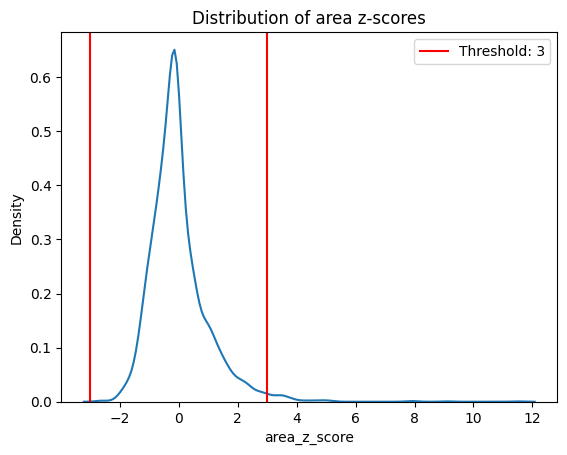

In [ ]:
# Visualize the distribution of area z-scores
sns.kdeplot(df['area_z_score'])

# Indicating the threshold
plt.axvline(threshold, color='r', label=f'Threshold: {threshold}')
plt.axvline(-threshold, color='r')

plt.title("Distribution of area z-scores")
plt.legend()
plt.show()

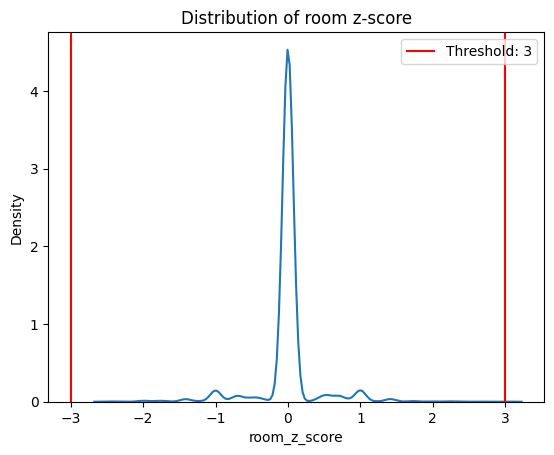

In [ ]:
# Visualize the distribution of room z-scores
sns.kdeplot(df['room_z_score'])

# Indicating the threshold
plt.axvline(threshold, color='r', label=f'Threshold: {threshold}')
plt.axvline(-threshold, color='r')

plt.title("Distribution of room z-score")
plt.legend()
plt.show()

In [ ]:
df['room_outlier'] = False
df['area_outlier'] = False
df.loc[(df['room_z_score'] > threshold) | (df['room_z_score'] < (-1*threshold)), 'room_outlier'] = True
df.loc[(df['area_z_score'] > threshold) | (df['area_z_score'] < (-1*threshold)), 'area_outlier'] = True

In [ ]:
df['Address'].dtypes

dtype('float64')

## In case you're curious to see the detected outliers, here they are:

In [ ]:
# Inverse transform the encoded labels to get original address names
df['Address'] = df['Address'].astype(int)
ad_names = encoder.inverse_transform(df['Address'])
df.insert(5, 'Address Name', ad_names)
df.loc[(df['room_outlier'] == True) | (df['area_outlier'] == True)]

,Area,Room,Parking,Warehouse,Elevator,Address Name,Address,Price,Price(USD),room_z_score,area_z_score,room_outlier,area_outlier
16,5.574000e+09,3.0,1.0,1.0,1.0,Narmak,100,6700000000,223333.33,0.0,4.898979,False,True
190,3.200000e+02,4.0,1.0,1.0,1.0,Saadat Abad,135,24000000000,800000.00,0.0,3.631578,False,True
194,5.422000e+09,2.0,1.0,1.0,0.0,Damavand,31,3500000000,116666.67,0.0,4.690416,False,True
339,3.350000e+02,4.0,1.0,1.0,1.0,Saadat Abad,135,33500000000,1116666.67,0.0,3.911373,False,True
340,3.200000e+02,4.0,1.0,1.0,1.0,Saadat Abad,135,40000000000,1333333.33,0.0,3.631578,False,True
364,4.912000e+09,3.0,1.0,1.0,1.0,Dorous,39,13800000000,460000.00,0.0,3.464102,False,True
395,2.570000e+02,4.0,1.0,1.0,1.0,Persian Gulf Martyrs Lake,119,12850000000,428333.33,0.0,3.975135,False,True
450,1.600000e+02,2.0,1.0,1.0,1.0,Pardis,117,1930000000,64333.33,0.0,3.782623,False,True
570,3.310000e+09,2.0,1.0,1.0,1.0,Ostad Moein,111,3310000000,110333.33,0.0,7.937254,False,True
613,1.600000e+02,2.0,1.0,1.0,1.0,Pardis,117,2000000000,66666.67,0.0,3.782623,False,True


In [ ]:
df = df.loc[(df['room_outlier'] == False) & (df['area_outlier'] == False)]

In [ ]:
len(df)

3227

# Distribution diagrams

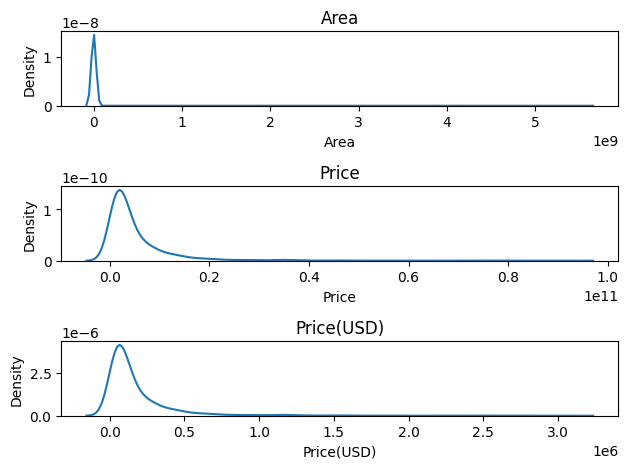

In [ ]:
# KDE diagrams for columns with continous values
for i, col in enumerate(["Area", "Price", "Price(USD)"]):
    plt.subplot(3, 1, i+1)
    sns.kdeplot(data=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

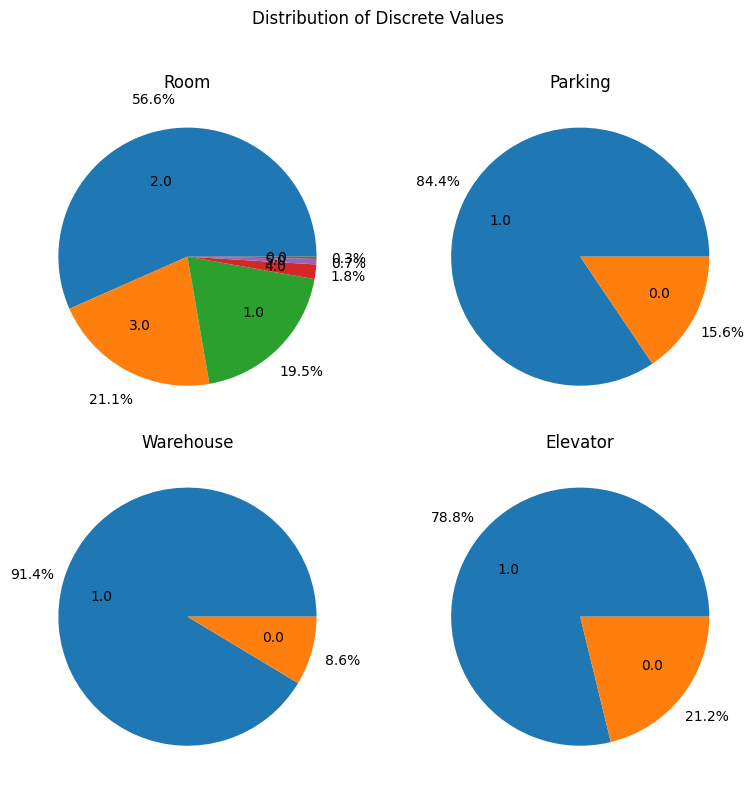

In [ ]:
# Pie charts for columns with discrete values
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
fig.suptitle('Distribution of Discrete Values')

for i, col in enumerate(["Room", "Parking", "Warehouse", "Elevator"]):
    ax = axs[i // 2, i % 2]
    sizes = df[col].value_counts().values
    labels = df[col].value_counts().index
    ax.pie(sizes, labels=labels, autopct='%1.1f%%',
           pctdistance=1.25, labeldistance=.6)
    ax.set_title(col)

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to make room for the title
plt.show()

# Plotting Regplots

<Axes: xlabel='Area', ylabel='Price'>

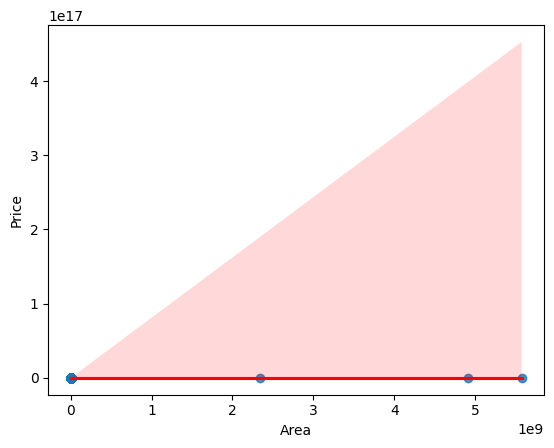

In [ ]:
sns.regplot(data=df, x="Area", y="Price", line_kws=dict(color="r"))

<Axes: xlabel='Room', ylabel='Price'>

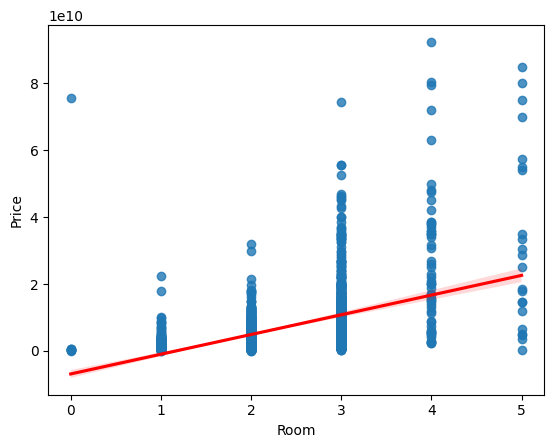

In [ ]:
sns.regplot(data=df, x="Room", y="Price", line_kws=dict(color="r"))

<Axes: xlabel='Price', ylabel='Warehouse'>

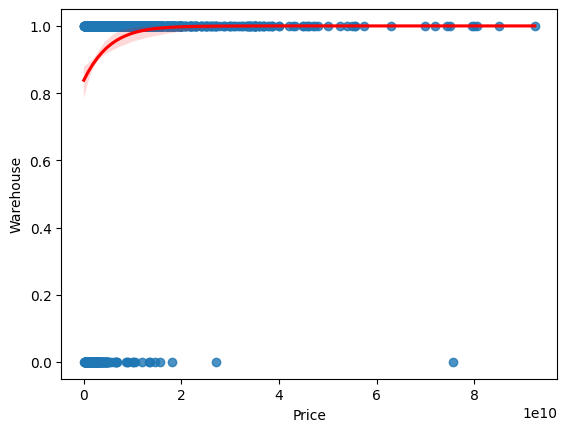

In [ ]:
sns.regplot(x=df["Price"], y=df["Warehouse"], logistic=True, line_kws=dict(color="r"))

<Axes: xlabel='Price', ylabel='Parking'>

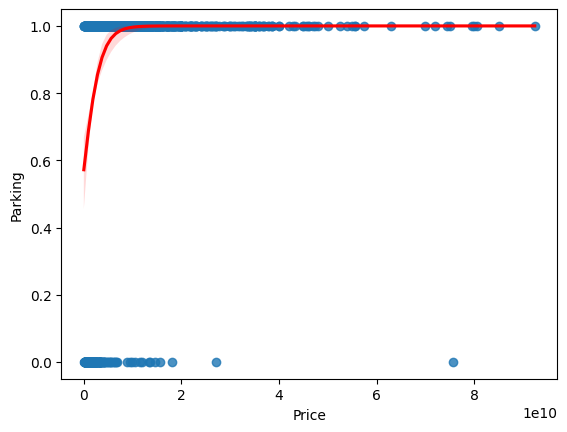

In [ ]:
sns.regplot(x=df["Price"], y=df["Parking"], logistic=True, line_kws=dict(color="r"))

<Axes: xlabel='Price', ylabel='Elevator'>

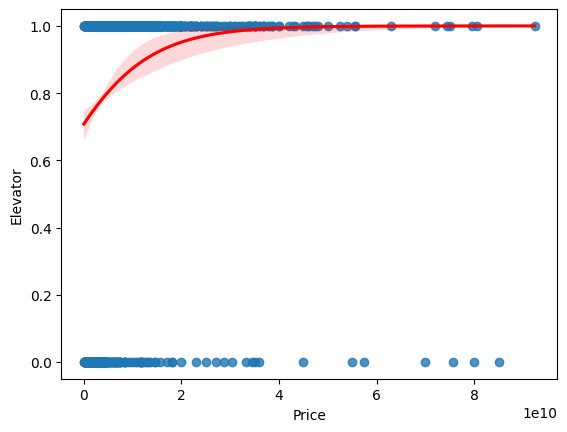

In [ ]:
sns.regplot(x=df["Price"], y=df["Elevator"], logistic=True, line_kws=dict(color="r"))

## Plotting Scatter Plots

Text(0, 0.5, 'Price')

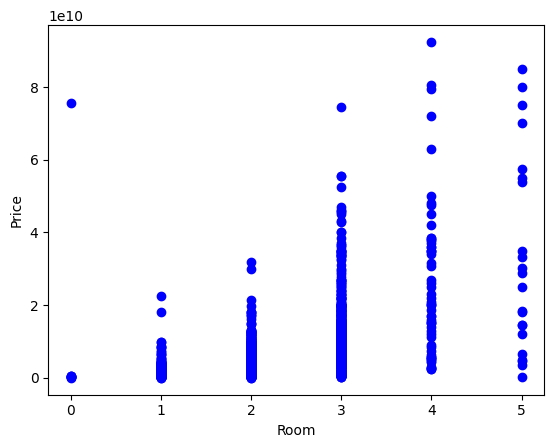

In [ ]:
plt.scatter(df.Room, df.Price,  color='blue')
plt.xlabel("Room")
plt.ylabel("Price")

Text(0, 0.5, 'Price')

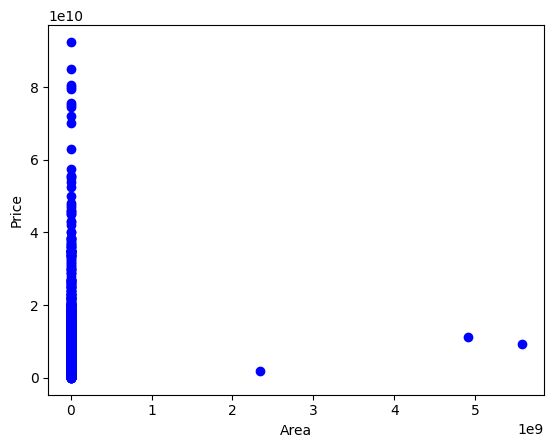

In [ ]:
plt.scatter(df.Area, df.Price,  color='blue')
plt.xlabel("Area")
plt.ylabel("Price")

Text(0, 0.5, 'Price')

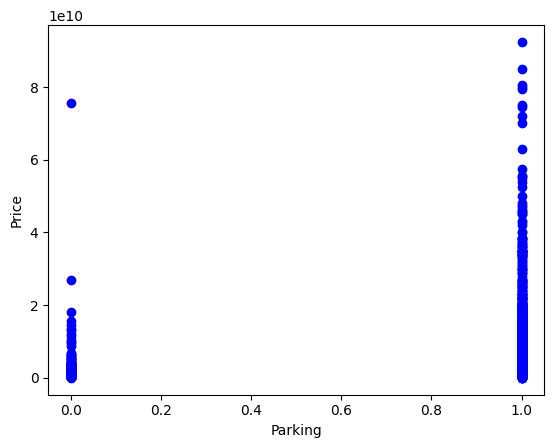

In [ ]:
plt.scatter(df.Parking, df.Price,  color='blue')
plt.xlabel("Parking")
plt.ylabel("Price")

# Define x(features) and y(lables)

In [ ]:
x = df[["Area",	"Room",	"Parking", "Warehouse",	"Elevator",	"Address"]]
y = df[['Price','Price(USD)']]

# Normalize Dataset

In [ ]:
scale = preprocessing.StandardScaler().fit(x)
x = scale.fit_transform(x)

# Train_Test split

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split( x, y, test_size=0.2, random_state=0)

# Multiple Regression

In [ ]:
from sklearn import linear_model
regr = linear_model.LinearRegression()
regr.fit(x_train, y_train)

LinearRegression()

# Evaluation

In [ ]:
from sklearn.metrics import r2_score
y_pred = regr.predict(x_test)
r2_score(y_test,y_pred)

0.32969183294546284

# Polynomial Regression

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree = 3)
x_trainpoly = poly.fit_transform(x_train)
x_testpoly = poly.fit_transform(x_test)
regr.fit(x_trainpoly, y_train)

LinearRegression()

# Evaluation

In [ ]:
from sklearn.metrics import r2_score
y_pred = regr.predict(x_testpoly)
r2_score(y_test,y_pred)

0.43381911601598694

# Random Forest Regression

In [ ]:
from sklearn.ensemble import RandomForestRegressor
regr = RandomForestRegressor(n_estimators = 10, random_state = 0)
regr.fit(x_train, y_train)

RandomForestRegressor(n_estimators=10, random_state=0)

# Evaluation

In [ ]:
from sklearn.metrics import r2_score
y_pred = regr.predict(x_test)
r2_score(y_test,y_pred)

0.7984002611467069

# Decision Tree Regression

In [ ]:
from sklearn.tree import DecisionTreeRegressor
regr = DecisionTreeRegressor(random_state = 0)
regr.fit(x_train, y_train)

DecisionTreeRegressor(random_state=0)

# Evaluation

In [ ]:
from sklearn.metrics import r2_score
y_pred = regr.predict(x_test)
r2_score(y_test,y_pred)

0.7259209249627383